<a href="https://colab.research.google.com/github/Krishna-97/ml-assessment-krishna-tk/blob/main/part_a/q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q2. Unsupervised Learning

**Task-1 Data Preparation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# Load the data
df = pd.read_csv('https://raw.githubusercontent.com/Krishna-97/ml-assessment-krishna-tk/main/data/q2_customers.csv')

# Inspect data
print("Data Head:")
print(df.head())
print("\nData Info:")
print(df.info())
# Data Preparation - Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)


Data Head:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_

**Task-2 Choosing K — Elbow Method**


WCSS Values: [3000.000000000002, 968.9938714074852, 561.2530064181284, 445.01242255413734, 418.23454127286044, 390.516973452165, 347.88882272837276, 351.67559247874476, 331.7876018466899, 289.113978541058]

Visualization Generated : Elbow_method.png


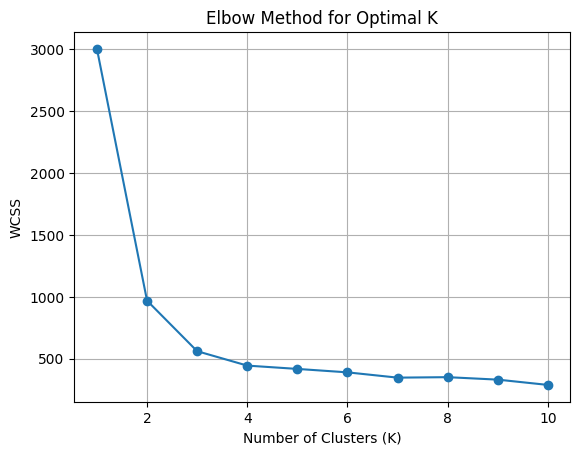

In [2]:
from sklearn.cluster import KMeans

# Elbow Method
wcss = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
#ploting the Elbow Method
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig('Elbow_method.png')
print("\nWCSS Values:",wcss)
print("\nVisualization Generated : Elbow_method.png")
plt.show()


**Task-3 K-Means Clustering**

In [3]:
# Optimal K =3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)
# Cluster Centroids (Inverse transform to get original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1])
centroids_df.index.name = 'Cluster'
print("\nCluster Centroids (Original Scale):")
print(centroids_df)


Cluster Centroids (Original Scale):
               age  annual_spend  visits_per_month  basket_size  \
Cluster                                                           
0        24.676471  14847.370588         14.341176   558.970588   
1        56.769697  89413.333333          2.527273  5530.545455   
2        40.387879  43340.733333          8.193939  2021.684848   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                     9.076471                  2.111765  
1                   105.357576                  7.515152  
2                    35.187879                  4.424242  


**Task-4 Dimensionality Reduction with PCA**

In [8]:
from sklearn.decomposition import PCA
# PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

#PCA Explained Variance
pca_explained_variance = pca.explained_variance_ratio_
print("\nPCA Explained Variance Ratio:", pca_explained_variance)
print(f"PC1 Explained Variance: {pca_explained_variance[0]:.4f}")
print(f"PC2 Explained Variance: {pca_explained_variance[1]:.4f}")

#PCA Loadings
pca_loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df.columns[:-1])
print("\nPCA Feature Loadings:")
print(pca_loadings)


PCA Explained Variance Ratio: [0.83560354 0.05568764]
PC1 Explained Variance: 0.8356
PC2 Explained Variance: 0.0557

PCA Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


**Task-5 Cluster Visualisation**

Visualization Generated : PCA_Clusters.png


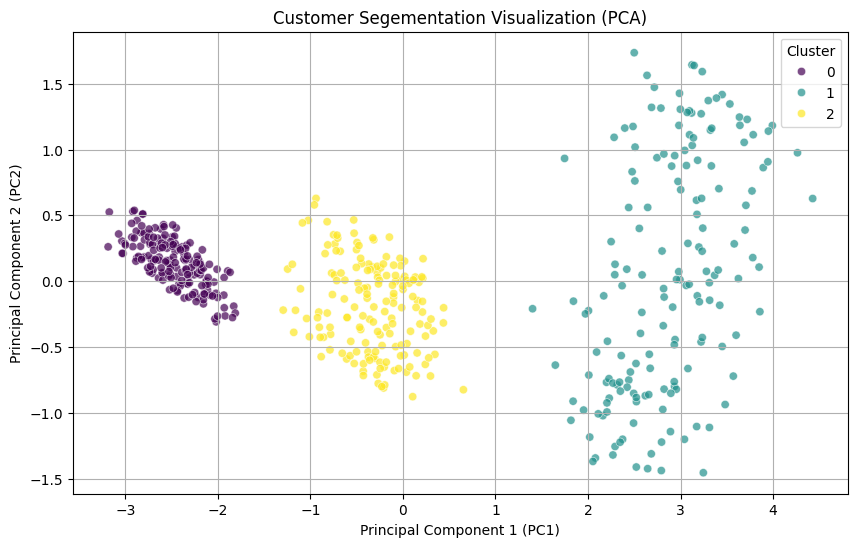

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='viridis',alpha=0.7)
plt.title('Customer Segementation Visualization (PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.savefig('PCA_Clusters.png')
print('Visualization Generated : PCA_Clusters.png')
plt.show()
